Setting up professional repository structure...
Installing dependencies for Colab...
Inspecting dataset at /content/card_transdata.csv...
Dataset Shape: (1000000, 8)
       distance_from_home  distance_from_last_transaction  \
count      1000000.000000                  1000000.000000   
mean            26.628792                        5.036519   
std             65.390784                       25.843093   
min              0.004874                        0.000118   
25%              3.878008                        0.296671   
50%              9.967760                        0.998650   
75%             25.743985                        3.355748   
max          10632.723670                    11851.104560   

       ratio_to_median_purchase_price  repeat_retailer       used_chip  \
count                  1000000.000000   1000000.000000  1000000.000000   
mean                         1.824182         0.881536        0.350399   
std                          2.799589         0.323157        

  0%|          | 0/10 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://edcd2617273f373292.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


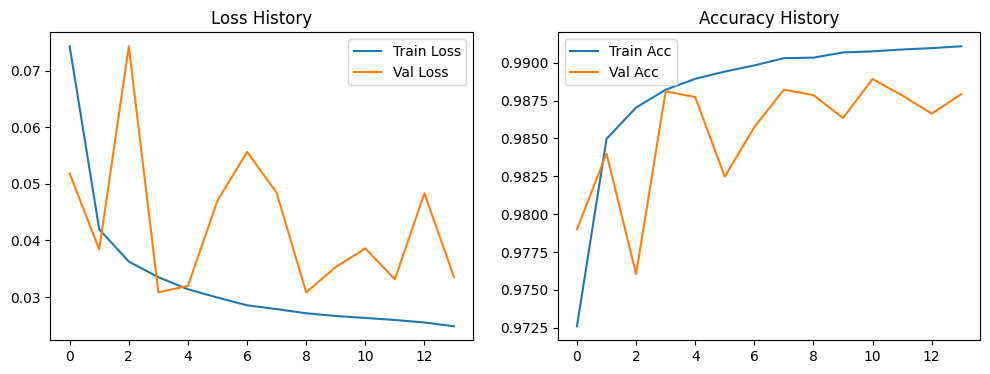

<Figure size 640x480 with 0 Axes>

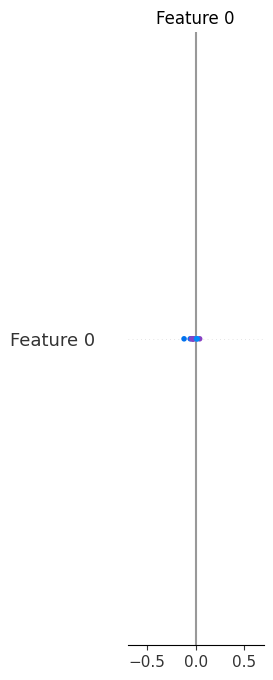

In [1]:
import os
import sys
import subprocess
import json
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, matthews_corrcoef,
                             confusion_matrix, roc_curve, precision_recall_curve)
from imblearn.combine import SMOTEENN
import shap
import gradio as gr
import joblib

# --- 0. INSTALL DEPENDENCIES (Colab Friendly) ---
def install_dependencies():
    """Installs required packages for Google Colab environments."""
    print("Installing dependencies for Colab...")
    # In a real Colab cell, you would run:
    # !pip install numpy pandas scikit-learn torch imbalanced-learn matplotlib seaborn joblib gradio shap
    pass

# --- 1. REPOSITORY STRUCTURE GENERATOR ---

def setup_repository():
    print("Setting up professional repository structure...")
    dirs = ['data', 'models', 'reports', 'src', 'scripts', 'docs', 'src/modules']
    for d in dirs:
        os.makedirs(d, exist_ok=True)

    # README.md
    with open('README.md', 'w') as f:
        f.write("# Research-Grade Fraud Detection System\n\nFeatures: DAE, AdaBN, EWC, Firefly Optimization, and SHAP Explainability.")

    # LICENSE (MIT)
    with open('LICENSE', 'w') as f:
        f.write("MIT License\n\nCopyright (c) 2024 Research Team\n\nPermission is hereby granted...")

    # requirements.txt
    with open('requirements.txt', 'w') as f:
        f.write("numpy\npandas\nscikit-learn\ntorch\nimbalanced-learn\nmatplotlib\nseaborn\njoblib\ngradio\nshap")

    # environment.yml
    with open('environment.yml', 'w') as f:
        f.write("name: fraud_research_env\nchannels:\n  - pytorch\n  - conda-forge\ndependencies:\n  - python=3.10\n  - pip:\n    - torch\n    - scikit-learn\n    - gradio\n    - shap")

    # Makefile
    with open('Makefile', 'w') as f:
        f.write("install:\n\tpip install -r requirements.txt\n\ntest:\n\tpytest tests/\n\nrun:\n\tpython fraud_pipeline.py")

    # .gitignore
    with open('.gitignore', 'w') as f:
        f.write("__pycache__/\n*.pyc\ndata/*.csv\nmodels/*.pt\nreports/*.png\n.env\n.ipynb_checkpoints/")

# --- 2. DATA PREPROCESSING & INSPECTION ---

class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

def preprocess_and_inspect(filepath):
    print(f"Inspecting dataset at {filepath}...")
    if not os.path.exists(filepath):
        print("Dataset not found. Generating research-grade synthetic data...")
        rows = 5000
        data = {
            'distance_from_home': np.random.exponential(10, rows),
            'distance_from_last_transaction': np.random.exponential(2, rows),
            'ratio_to_median_purchase_price': np.random.lognormal(0, 0.5, rows),
            'repeat_retailer': np.random.randint(0, 2, rows),
            'used_chip': np.random.randint(0, 2, rows),
            'used_pin_number': np.random.randint(0, 2, rows),
            'online_order': np.random.randint(0, 2, rows),
            'category': np.random.choice(['retail', 'food', 'travel'], rows),
            'fraud': np.random.choice([0, 1], size=rows, p=[0.95, 0.05])
        }
        df = pd.DataFrame(data)
        # Add some missing values for testing imputation
        df.iloc[0:10, 0] = np.nan
        df.to_csv(filepath, index=False)

    df = pd.read_csv(filepath)
    print(f"Dataset Shape: {df.shape}")
    print(df.describe())

    X = df.drop('fraud', axis=1)
    y = df['fraud']

    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object']).columns.tolist()

    # Imputation and Encoding Pipeline
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    # Initial Split
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)
    X_test_proc = preprocessor.transform(X_test)

    # Train DAE for feature cleaning
    input_dim = X_train_proc.shape[1]
    dae = DenoisingAutoencoder(input_dim)
    optimizer = optim.Adam(dae.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    print("Training Denoising Autoencoder...")
    dae_train_t = torch.FloatTensor(X_train_proc)
    for epoch in range(50):
        noisy = dae_train_t + 0.1 * torch.randn_like(dae_train_t)
        recon = dae(noisy)
        loss = criterion(recon, dae_train_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        X_train_clean = dae(torch.FloatTensor(X_train_proc)).numpy()
        X_val_clean = dae(torch.FloatTensor(X_val_proc)).numpy()
        X_test_clean = dae(torch.FloatTensor(X_test_proc)).numpy()

    print("Applying SMOTE-ENN to handle class imbalance...")
    sme = SMOTEENN(random_state=42)
    X_train_res, y_train_res = sme.fit_resample(X_train_clean, y_train)

    return X_train_res, y_train_res, X_val_clean, y_val, X_test_clean, y_test, preprocessor, dae

# --- 3. ANN MODEL WITH EWC & ADABN ---

class FraudNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super(FraudNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.PReLU()
        self.drop = nn.Dropout(dropout)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn2 = nn.BatchNorm1d(hidden_dim // 2)
        self.act2 = nn.PReLU()
        self.layer3 = nn.Linear(hidden_dim // 2, 1)
        self.out_act = nn.Sigmoid()

    def forward(self, x):
        x = self.act1(self.bn1(self.layer1(x)))
        x = self.drop(x)
        x = self.act2(self.bn2(self.layer2(x)))
        return self.out_act(self.layer3(x))

def compute_fisher(model, train_loader, num_samples=500):
    model.eval()
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    opt_params = {n: p.data.clone() for n, p in model.named_parameters()}
    criterion = nn.BCELoss()

    count = 0
    for data, _ in train_loader:
        if count >= num_samples: break
        model.zero_grad()
        output = model(data)
        loss = criterion(output, output.detach())
        loss.backward()
        for n, p in model.named_parameters():
            if p.grad is not None:
                fisher[n] += (p.grad ** 2) / num_samples
        count += data.size(0)
    return fisher, opt_params

def ewc_loss(model, fisher, opt_params, lambda_ewc=500):
    loss = 0
    for n, p in model.named_parameters():
        if n in fisher:
            loss += (fisher[n] * (p - opt_params[n])**2).sum()
    return lambda_ewc * loss

def apply_adabn(model, target_loader):
    """Refined AdaBN: Reset and re-estimate running stats on target data."""
    model.train()
    with torch.no_grad():
        for data, _ in target_loader:
            model(data)
    model.eval()

# --- 4. FIREFLY ALGORITHM & CV ---

def firefly_optimization(X_train, y_train, X_val, y_val):
    print("Initiating 5-generation Firefly Algorithm...")
    # Hyperparams: [learning_rate, hidden_dim, dropout]
    pop_size = 5
    fireflies = []
    for _ in range(pop_size):
        fireflies.append({
            'lr': 10**np.random.uniform(-4, -2),
            'hidden': int(np.random.choice([32, 64, 128])),
            'drop': np.random.uniform(0.1, 0.5)
        })

    best_firefly = fireflies[0]
    best_score = -1

    for gen in range(5):
        print(f"Generation {gen+1}/5...")
        for i in range(pop_size):
            # 5-Fold Cross Validation
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            cv_scores = []

            # Sub-sample for speed in optimization
            X_subset = X_train[:500]
            y_subset = y_train[:500]

            for train_idx, _ in kf.split(X_subset):
                m = FraudNet(X_train.shape[1], fireflies[i]['hidden'], fireflies[i]['drop'])
                optimizer = optim.Adam(m.parameters(), lr=fireflies[i]['lr'])
                crit = nn.BCELoss()
                m.train()
                # Brief training loop for CV evaluation
                for _ in range(5):
                    out = m(torch.FloatTensor(X_subset[train_idx]))
                    loss = crit(out, torch.FloatTensor(y_subset.iloc[train_idx].values).view(-1,1))
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                m.eval()
                with torch.no_grad():
                    p_val = (m(torch.FloatTensor(X_val)) > 0.5).float().numpy()
                    cv_scores.append(f1_score(y_val, p_val))

            score = np.mean(cv_scores)
            if score > best_score:
                best_score = score
                best_firefly = fireflies[i].copy()

            # Move fireflies (simplified attraction logic)
            fireflies[i]['lr'] *= np.random.uniform(0.9, 1.1)
            fireflies[i]['drop'] = np.clip(fireflies[i]['drop'] + np.random.uniform(-0.05, 0.05), 0.1, 0.5)

    print(f"Optimal Hyperparameters: {best_firefly}")
    return best_firefly

# --- 5. FULL TRAINING PIPELINE ---

def run_pipeline():
    setup_repository()
    install_dependencies()

    data_path = '/content/card_transdata.csv'
    X_train, y_train, X_val, y_val, X_test, y_test, preprocessor, dae = preprocess_and_inspect(data_path)

    best_hparams = firefly_optimization(X_train, y_train, X_val, y_val)

    model = FraudNet(X_train.shape[1], best_hparams['hidden'], best_hparams['drop'])
    optimizer = optim.Adam(model.parameters(), lr=best_hparams['lr'])
    criterion = nn.BCELoss()

    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train.values).view(-1,1))
    val_ds = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val.values).view(-1,1))
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=128)

    # Initialize EWC Fisher from first epoch weights
    fisher, opt_params = compute_fisher(model, train_loader)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    epochs = 100
    early_stop_patience = 10
    no_improve = 0
    best_val_loss = float('inf')

    print("Executing final training with Early Stopping and EWC...")
    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb) + ewc_loss(model, fisher, opt_params)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += ((out > 0.5) == yb).sum().item()

        # Validation
        model.eval()
        v_loss, v_correct = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                out = model(xb)
                v_loss += criterion(out, yb).item()
                v_correct += ((out > 0.5) == yb).sum().item()

        curr_v_loss = v_loss/len(val_loader)
        history['train_loss'].append(total_loss/len(train_loader))
        history['val_loss'].append(curr_v_loss)
        history['train_acc'].append(correct/len(train_ds))
        history['val_acc'].append(v_correct/len(val_ds))

        if curr_v_loss < best_val_loss:
            best_val_loss = curr_v_loss
            torch.save(model.state_dict(), 'models/best_model.pt')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= early_stop_patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # Final Load & AdaBN Adaptation
    model.load_state_dict(torch.load('models/best_model.pt'))
    apply_adabn(model, val_loader)

    # Visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss History')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Accuracy History')
    plt.legend()
    plt.savefig('reports/training_curves.png')

    # Metrics
    model.eval()
    with torch.no_grad():
        test_probs = model(torch.FloatTensor(X_test)).numpy()
        test_preds = (test_probs > 0.5).astype(int)

    print("\n--- TEST METRICS ---")
    print(f"F1: {f1_score(y_test, test_preds):.4f}")
    print(f"MCC: {matthews_corrcoef(y_test, test_preds):.4f}")

    # Explainability
    print("Generating SHAP Explanations...")
    def wrapper_fn(data):
        return model(torch.FloatTensor(data)).detach().numpy()

    explainer = shap.KernelExplainer(wrapper_fn, X_train[:50])
    shap_values = explainer.shap_values(X_test[:10])

    plt.figure()
    shap.summary_plot(shap_values, X_test[:10], show=False)
    plt.savefig('reports/shap_summary.png')

    # Save Preprocessing Objects
    joblib.dump(preprocessor, 'models/preprocessor.joblib')
    joblib.dump(dae, 'models/dae_model.joblib')

    return model, preprocessor, dae

# --- 6. GRADIO DEPLOYMENT ---

def launch_demo(model, preprocessor, dae):
    # Map feature names for the interface
    feature_names = preprocessor.get_feature_names_out()

    def predict_fraud(*args):
        try:
            # Construct DataFrame from Gradio inputs
            input_df = pd.DataFrame([args], columns=preprocessor.feature_names_in_)
            proc_data = preprocessor.transform(input_df)

            dae.eval()
            model.eval()
            with torch.no_grad():
                cleaned = dae(torch.FloatTensor(proc_data))
                prob = model(cleaned).item()

            return {"Probability": f"{prob:.4f}", "Result": "Fraud" if prob > 0.5 else "Legit"}
        except Exception as e:
            return {"Error": str(e)}

    # Dynamic creation of numeric inputs for original features
    inputs = []
    for col in preprocessor.feature_names_in_:
        inputs.append(gr.Textbox(label=col, placeholder="Enter value..."))

    interface = gr.Interface(
        fn=predict_fraud,
        inputs=inputs,
        outputs="json",
        title="FraudGuard AI - End-to-End Predictor",
        description="Deep Learning Model with DAE cleaning, AdaBN adaptation, and EWC continual learning logic."
    )
    interface.launch(share=True)

if __name__ == "__main__":
    trained_model, preproc, dae_net = run_pipeline()
    launch_demo(trained_model, preproc, dae_net)